Bài Tập Thực Hành Trực Quan Hóa Dữ Liệu: COVID-19 tại Đông Nam Á
Chuẩn bị Dữ liệu (Data Preparation)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Cài đặt style chung cho Seaborn
sns.set_theme(style="whitegrid")

# 1. Tải dữ liệu trực tiếp từ Our World in Data (có thể mất 1-2 phút)
url = 'https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv'
print("Đang tải dữ liệu...")
df_raw = pd.read_csv(url)

# 2. Lọc dữ liệu khu vực Đông Nam Á & Giới hạn thời gian (2021 - 2022)
asean_countries = ['Vietnam', 'Thailand', 'Indonesia', 'Malaysia', 'Singapore', 'Philippines']
df = df_raw[df_raw['location'].isin(asean_countries)].copy()

df['date'] = pd.to_datetime(df['date'])
df = df[(df['date'] >= '2021-01-01') & (df['date'] <= '2022-12-31')]

# 3. Lọc ra các cột quan trọng cần thiết cho bài tập
cols_to_keep = [
    'location', 'date', 'new_cases', 'new_deaths',
    'new_tests', 'total_vaccinations', 'people_fully_vaccinated_per_hundred'illna
]
df = df[cols_to_keep]

# 4. Xử lý NaN cơ bản (Điền 0 cho ca mắc/tử vong/test mới; fill forward cho vaccine vì là số liệu tích lũy)
df[['new_cases', 'new_deaths', 'new_tests']] = df[['new_cases', 'new_deaths', 'new_tests']].f(0)
df['total_vaccinations'] = df.groupby('location')['total_vaccinations'].ffill().fillna(0)
df['people_fully_vaccinated_per_hundred'] = df.groupby('location')['people_fully_vaccinated_per_hundred'].ffill().fillna(0)

print(df)

Đang tải dữ liệu...
         location       date  new_cases  new_deaths  new_tests  \
175593  Indonesia 2021-01-01        0.0         0.0        0.0   
175594  Indonesia 2021-01-02        0.0         0.0        0.0   
175595  Indonesia 2021-01-03    51985.0      1497.0        0.0   
175596  Indonesia 2021-01-04        0.0         0.0        0.0   
175597  Indonesia 2021-01-05        0.0         0.0        0.0   
...           ...        ...        ...         ...        ...   
419269    Vietnam 2022-12-27        0.0         0.0        0.0   
419270    Vietnam 2022-12-28        0.0         0.0        0.0   
419271    Vietnam 2022-12-29        0.0         0.0        0.0   
419272    Vietnam 2022-12-30        0.0         0.0        0.0   
419273    Vietnam 2022-12-31        0.0         0.0        0.0   

        total_vaccinations  people_fully_vaccinated_per_hundred  
175593                 0.0                                 0.00  
175594                 0.0                             

Câu 1: Phân phối cơ bản (Histogram)





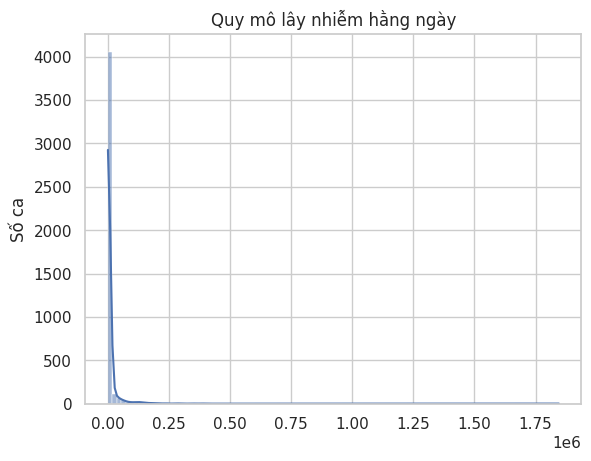

In [ ]:
sns.histplot(data=df, x ="new_cases", bins=50, kde=True)
plt.title("Quy mô lây nhiễm hằng ngày")
plt.xlabel("")
plt.ylabel("Số ca")
plt.show()

Câu 2: Biến động theo thời gian (Line Chart)


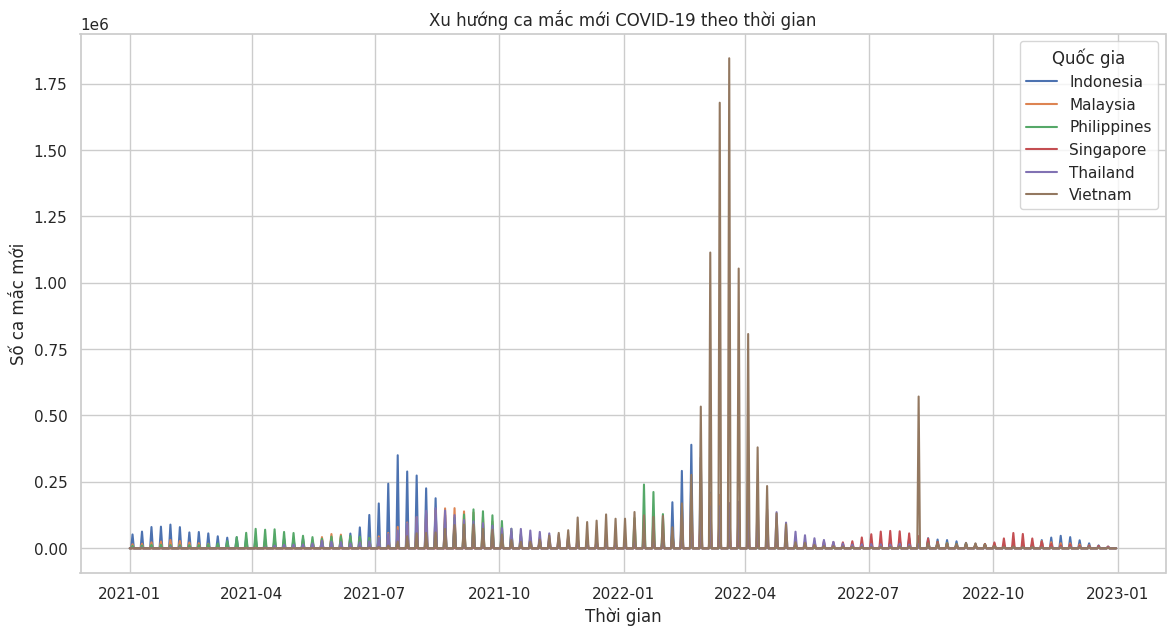

In [ ]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=df, x='date', y='new_cases', hue='location')
plt.title('Xu hướng ca mắc mới COVID-19 theo thời gian')
plt.xlabel('Thời gian')
plt.ylabel('Số ca mắc mới')
plt.legend(title='Quốc gia')
plt.show()

Câu 3: Tổng kết mất mát (Bar Chart)

/tmp/ipykernel_67492/2786115927.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_deaths, x='location', y='new_deaths', palette='Reds_r')


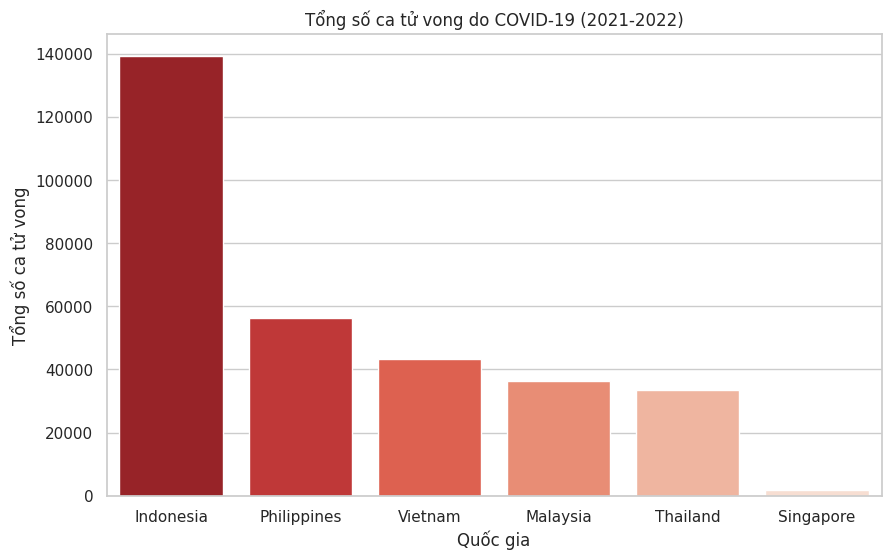

In [ ]:
# Chuẩn bị dữ liệu
df_deaths = df.groupby('location')['new_deaths'].sum().reset_index().sort_values(by='new_deaths', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_deaths, x='location', y='new_deaths', palette='Reds_r')
plt.title('Tổng số ca tử vong do COVID-19 (2021-2022)')
plt.xlabel('Quốc gia')
plt.ylabel('Tổng số ca tử vong')
plt.show()

Câu 4: Phân bổ nỗ lực phòng dịch (Pie Chart)

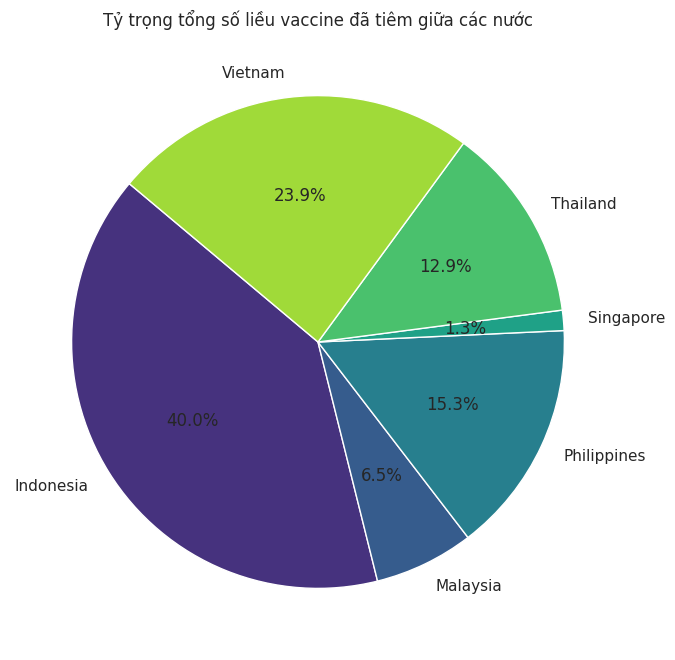

In [ ]:
# Lấy con số tiêm chủng cuối cùng (lớn nhất) của mỗi nước
df_vaccine = df.groupby('location')['total_vaccinations'].max()

plt.figure(figsize=(8, 8))
plt.pie(df_vaccine, labels=df_vaccine.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis'))
plt.title('Tỷ trọng tổng số liều vaccine đã tiêm giữa các nước')
plt.show()

Câu 5: Đo lường sự bất ổn (Box Plot)

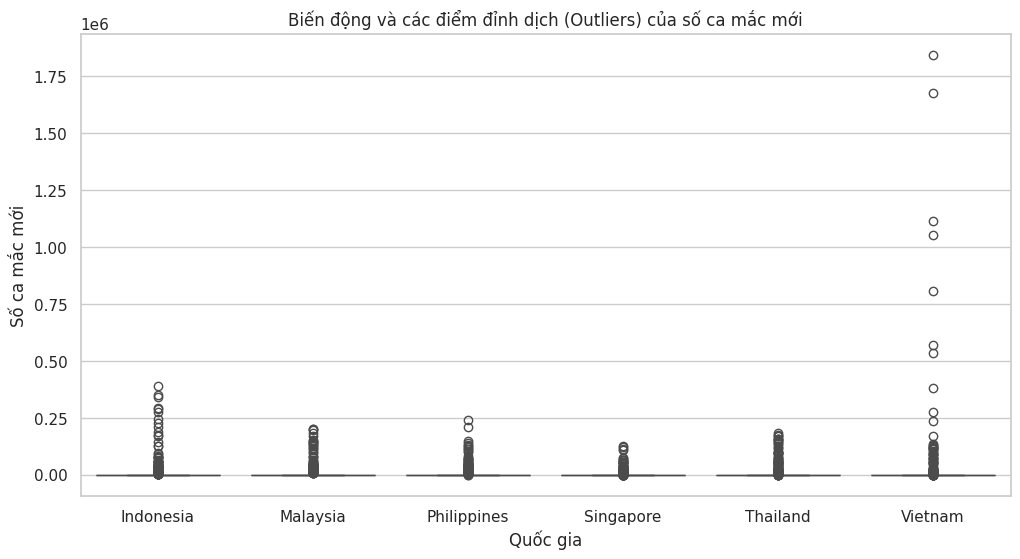

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='location', y='new_cases')
plt.title('Biến động và các điểm đỉnh dịch (Outliers) của số ca mắc mới')
plt.xlabel('Quốc gia')
plt.ylabel('Số ca mắc mới')
plt.show()

Câu 6: Năng lực y tế và lây nhiễm (Scatter Plot)

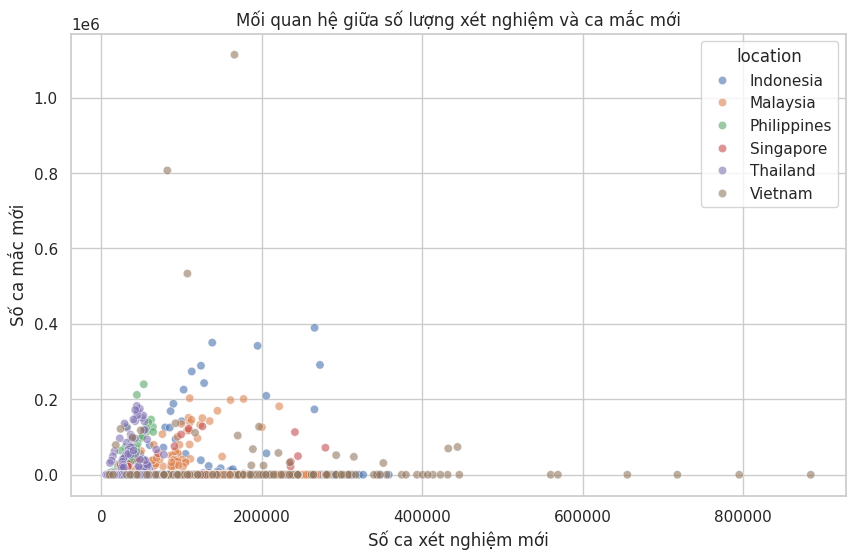

In [ ]:
# Lọc dữ liệu có xét nghiệm > 0 để tránh nhiễu
df_test = df[df['new_tests'] > 0]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_test, x='new_tests', y='new_cases', hue='location', alpha=0.6)
plt.title('Mối quan hệ giữa số lượng xét nghiệm và ca mắc mới')
plt.xlabel('Số ca xét nghiệm mới')
plt.ylabel('Số ca mắc mới')
plt.show()

Câu 7: Bức tranh toàn cảnh (Heatmap)

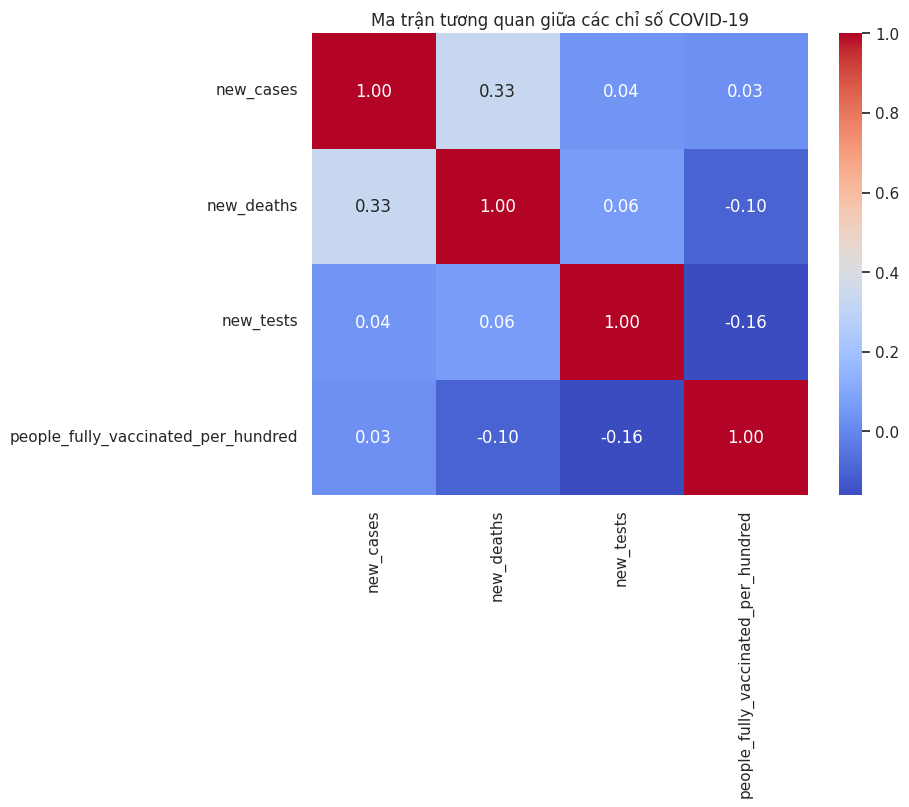

In [ ]:
# Lọc các cột cần thiết
cols = ['new_cases', 'new_deaths', 'new_tests', 'people_fully_vaccinated_per_hundred']
corr_matrix = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận tương quan giữa các chỉ số COVID-19')
plt.show()

Câu 8: Chứng minh hiệu quả Vắc-xin (Linear Regression Plot)

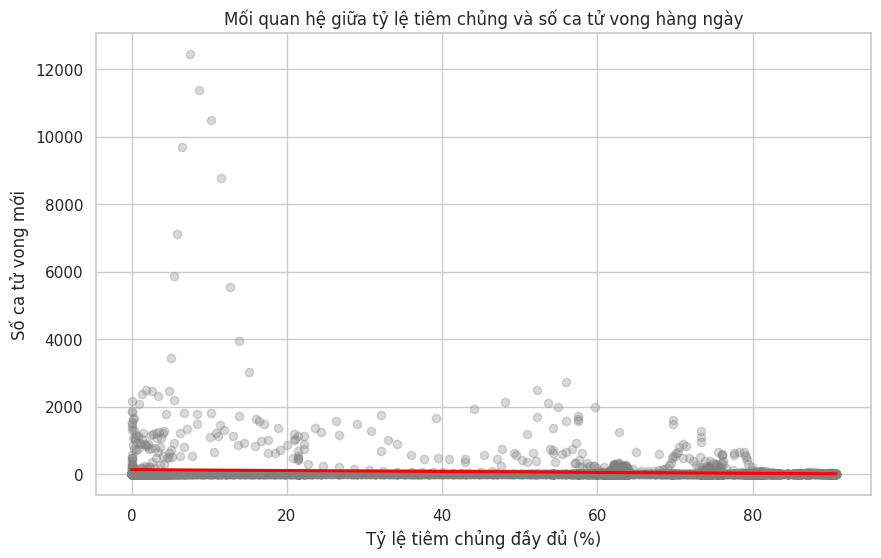

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='people_fully_vaccinated_per_hundred', y='new_deaths',
            scatter_kws={'alpha':0.3, 'color':'gray'}, line_kws={'color':'red'})
plt.title('Mối quan hệ giữa tỷ lệ tiêm chủng và số ca tử vong hàng ngày')
plt.xlabel('Tỷ lệ tiêm chủng đầy đủ (%)')
plt.ylabel('Số ca tử vong mới')
plt.show()